In [1]:
import numpy as np
import matplotlib.pyplot as plt
import fastddm as ddm

In [2]:
def gaussian_pdf(D, mu, sigma):
    D = np.asarray(D)
    pdf = np.exp(-0.5 * ((D - mu) / sigma) ** 2)
    pdf[D <= 0] = 0.0
    return pdf

def normalize_pdf(D, pdf):
    Z = np.trapezoid(pdf, D)
    return pdf / Z, Z

In [3]:
mu_D = 1.0 
sigma_D = 0.2

D_min = 0.0
D_max = mu_D + 6.0 * sigma_D
D_grid = np.linspace(D_min, D_max, 8000)

P_gaus = gaussian_pdf(D_grid, mu_D, sigma_D)
P_grid, Z = normalize_pdf(D_grid, P_gaus)

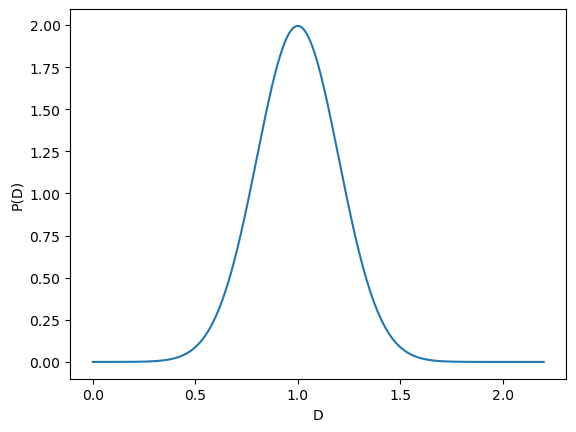

In [4]:
plt.figure()
plt.plot(D_grid, P_grid)
plt.xlabel("D")
plt.ylabel("P(D)")
plt.show()

In [5]:
def simulation(D_grid, P_grid, q_vals, t_vals):
    """
    Simulate f(q,t) via numerical integration on D_grid.
    Returns f with shape (N1, Nt).
    """
    Nq = len(q_vals)
    Nt = len(t_vals)
    f = np.empty((Nq, Nt), dtype=float)

    for i, q in enumerate(q_vals):
        qq = q * q
        for j, t in enumerate(t_vals):
            integrand = P_grid * np.exp(-D_grid * qq * t)
            f[i, j] = np.trapezoid(integrand, D_grid)
    return f

q_vals = np.linspace(0.5, 3.0, 25)     
t_vals = np.logspace(np.log(0.001)/np.log(10), np.log(200)/np.log(10))    
#t_vals = np.logspace(-3, np.log10(200))    

f_mat = simulation(D_grid, P_grid, q_vals, t_vals)  

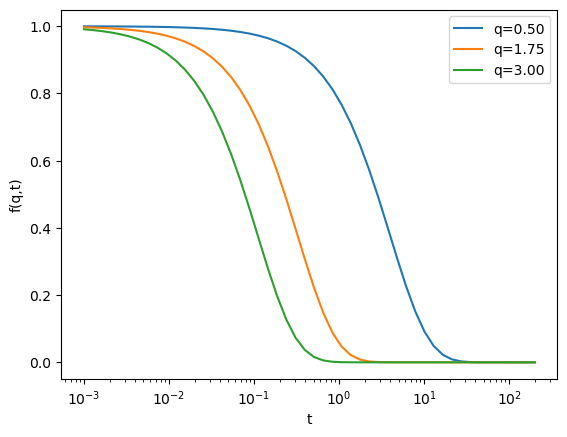

In [6]:
plt.figure()
for q in [q_vals[0], q_vals[len(q_vals)//2], q_vals[-1]]:
    i = np.argmin(np.abs(q_vals - q))
    plt.semilogx(t_vals, f_mat[i], label=f"q={q_vals[i]:.2f}")
plt.xlabel("t")
plt.ylabel("f(q,t)")
plt.legend()
plt.show()

In [7]:
def cumulant(q_vals, t_vals, f_mat, f_min=0.05):
    xa = []
    ya = []
    for i, q in enumerate(q_vals):
        qq = q * q
        for j, t in enumerate(t_vals):
            f = f_mat[i, j]
            if f>=f_min:
                x = qq * t
                y = np.log(f)
                xa.append(x)
                ya.append(y)
    xa = np.asarray(xa)
    ya = np.asarray(ya)
    X = np.column_stack([xa, xa**2,xa**3])
    coeffs, residuals, _, _ = np.linalg.lstsq(X, ya)
    a, b, c = coeffs
    m1 = -a
    m2 = 2.0 * b
    m3 = - 6.0 * c
    
    y_pred = X @ coeffs
    rmse = np.sqrt(np.mean((ya - y_pred)**2))
    print(rmse)
    
    return m1, m2, m3
    
m1, m2, m3 = cumulant(q_vals, t_vals, f_mat)

1.58489674348529e-08


In [8]:
xa = []
ya = []

for i, q in enumerate(q_vals):
    qq = q*q
    for j, t in enumerate(t_vals):
        f = f_mat[i,j]
        if f > 0.05:
            x = qq*t
            y = np.log(f)
            xa.append(x)
            ya.append(y)

xa = np.array(xa)
ya = np.array(ya)

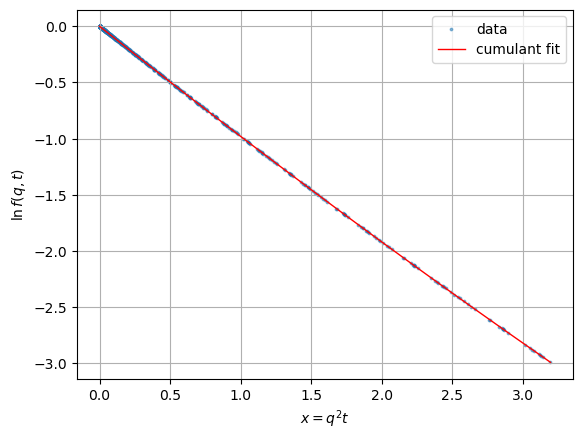

In [13]:
y_fit = -m1*xa + 0.5*m2*(xa**2) - (m3/6.0)*(xa**3)
order = np.argsort(xa)
plt.figure()
plt.scatter(xa, ya, s=3, alpha=0.5, label="data")
plt.plot(xa[order], y_fit[order], color="red", linewidth=1, label="cumulant fit")
plt.xlabel(r"$x = q^2 t$")
plt.ylabel(r"$\ln f(q,t)$")
plt.grid(True)

plt.legend()
plt.show()

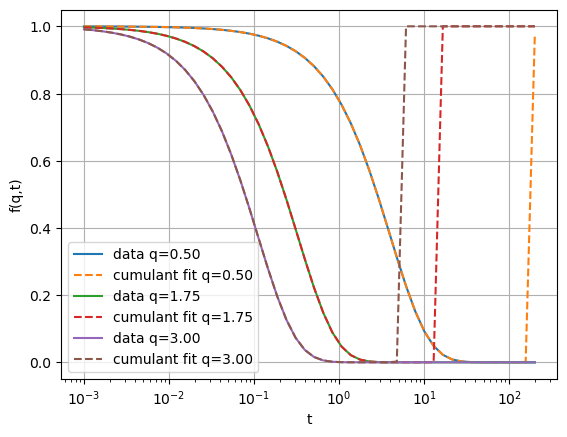

In [11]:
plt.figure()
q_list = [q_vals[0], q_vals[len(q_vals)//2], q_vals[-1]]

for q in q_list:
    i = np.argmin(np.abs(q_vals - q))
    q_use = q_vals[i]

    plt.semilogx(t_vals, f_mat[i], label=f"data q={q_use:.2f}")

    x_q = (q_use**2) * t_vals
    ln_f_fit = -m1*x_q + 0.5*m2*(x_q**2) - (m3/6.0)*(x_q**3)
    ln_f_fit = np.minimum(ln_f_fit, 0.0)
    f_fit = np.exp(ln_f_fit)

    plt.semilogx(t_vals, f_fit, "--", label=f"cumulant fit q={q_use:.2f}")

plt.xlabel("t")
plt.ylabel("f(q,t)")
plt.legend()
plt.grid(True)
plt.show()